In [1]:
import pandas as pd

In [2]:
# Load data
df = pd.read_csv("Superstore.csv", encoding="latin1")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Initial Data Inspection

The dataset contains **9,800 rows and 18 columns** representing customer orders, shipping information, product details, and sales values.

### Issues Identified

1. **Date Columns Stored as Text**

   * The `Order Date` and `Ship Date` columns were initially loaded as strings rather than datetime objects.
   * These columns use the format **DD/MM/YYYY**, which requires explicit conversion before performing time-based analysis.

2. **Postal Code Data Type**

   * The `Postal Code` column appears as a numeric field with decimal values (e.g., `42420.0`).
   * Postal codes are identifiers rather than numerical measurements, so they may need to be converted to strings to preserve formatting and avoid analytical issues.

3. **Potential Missing Values**

   * No missing-value assessment has been performed yet.
   * Further inspection is required to identify null values and determine whether imputation or removal is necessary.

4. **Truncated Text Fields**

   * Some product names are truncated in the displayed output due to notebook display limitations.
   * The underlying data should be verified to ensure product descriptions are complete.

5. **Data Quality Validation Needed**

   * Additional checks should be performed for duplicate records, inconsistent category labels, invalid sales values, and outliers.

### Next Steps

* Convert date columns to datetime format.
* Check for missing values and duplicates.
* Validate data types for all columns.
* Perform descriptive statistics and exploratory data analysis (EDA).
* Investigate sales trends by region, category, and time period.


In [3]:
# Fix date columns (stored as strings)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')

# Days to ship (new feature)
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Date columns fixed. New features added.")
df[['Order Date','Ship Date','Days to Ship']].head()

Date columns fixed. New features added.


,Order Date,Ship Date,Days to Ship
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


## Date Processing and Feature Engineering

The `Order Date` and `Ship Date` columns were successfully converted from text format to datetime format. This transformation enables time-based analysis such as trend identification, seasonality detection, and shipping performance evaluation.

### New Feature Created

**Days to Ship**

A new column, `Days to Ship`, was created by calculating the difference between `Ship Date` and `Order Date`.

[
\text{Days to Ship} = \text{Ship Date} - \text{Order Date}
]

This feature measures the number of days required to fulfill and ship an order.

### Sample Results

| Order Date | Ship Date  | Days to Ship |
| ---------- | ---------- | ------------ |
| 2017-11-08 | 2017-11-11 | 3            |
| 2017-11-08 | 2017-11-11 | 3            |
| 2017-06-12 | 2017-06-16 | 4            |
| 2016-10-11 | 2016-10-18 | 7            |
| 2016-10-11 | 2016-10-18 | 7            |

### Business Value

The `Days to Ship` metric can be used to:

* Evaluate shipping efficiency.
* Compare delivery performance across shipping modes.
* Identify delays and operational bottlenecks.
* Analyze customer service performance by region or product category.
* Support future logistics and supply chain optimization efforts.

### Next Steps

* Analyze the distribution of shipping times.
* Compare shipping performance across regions and shipping modes.
* Identify orders with unusually long fulfillment times.
* Explore relationships between shipping speed and sales performance.


In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Check for nulls and handle
null_cols = df.columns[df.isnull().any()].tolist()
print(f"Columns with nulls: {null_cols}")

# For numeric columns: fill with median
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Rename columns: remove spaces for SQL compatibility
df.columns = df.columns.str.strip().str.replace(' ', '_')

print(f"Clean shape: {df.shape}")
df.to_csv('train.csv', index=False)
print("Saved to data/clean/")

Columns with nulls: []
Clean shape: (9994, 25)
Saved to data/clean/


In [5]:
import pandas as pd
import sqlite3

df = pd.read_csv('train.csv')

conn = sqlite3.connect('sales.db')

df.to_sql('sales', conn, if_exists='replace', index=False)

print("Data loaded into SQLite — table: sales")

Data loaded into SQLite — table: sales


In [6]:
import pandas as pd

pd.read_sql("PRAGMA table_info(sales);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Row_ID,INTEGER,0,None,0
1,1,Order_ID,TEXT,0,None,0
2,2,Order_Date,TEXT,0,None,0
3,3,Ship_Date,TEXT,0,None,0
4,4,Ship_Mode,TEXT,0,None,0
5,5,Customer_ID,TEXT,0,None,0
6,6,Customer_Name,TEXT,0,None,0
7,7,Segment,TEXT,0,None,0
8,8,Country,TEXT,0,None,0
9,9,City,TEXT,0,None,0


In [7]:
q1 = """
SELECT Category,
       ROUND(SUM(Sales), 2)   AS total_revenue,
       ROUND(SUM(Profit), 2)  AS total_profit,
       ROUND(AVG(Discount), 3) AS avg_discount
FROM sales
GROUP BY Category
ORDER BY total_revenue DESC;
"""
pd.read_sql(q1, conn)

,Category,total_revenue,total_profit,avg_discount
0,Technology,836154.03,145454.95,0.132
1,Furniture,741999.80,18451.27,0.174
2,Office Supplies,719047.03,122490.80,0.157


# 📊 Category Performance Analysis

This table summarizes business performance across three categories using:
- Total Revenue
- Total Profit
- Average Discount

---

## 💻 Technology
- **Total Revenue:** 836,154.03 (highest)
- **Total Profit:** 145,454.95 (highest)
- **Avg Discount:** 0.132 (lowest)

### 📌 Insight:
Technology is the **best-performing category**.
- Generates the most revenue
- Produces the highest profit
- Relies less on discounts

👉 This suggests strong demand and healthier margins.

---

## 🪑 Furniture
- **Total Revenue:** 741,999.80
- **Total Profit:** 18,451.27 (very low)
- **Avg Discount:** 0.174 (highest)

### 📌 Insight:
Furniture has a **profitability problem**.
- Revenue is relatively high
- But profit is extremely low
- High discounts are likely reducing margins

⚠️ This category may be over-discounted or high-cost.

---

## 📎 Office Supplies
- **Total Revenue:** 719,047.03 (lowest)
- **Total Profit:** 122,490.80 (second highest)
- **Avg Discount:** 0.157

### 📌 Insight:
Office Supplies is **highly efficient**.
- Lower revenue but strong profit
- Balanced discount levels
- Likely good margins or low costs

---

## 📌 Key Takeaways

- 💰 **Most profitable:** Technology  
- ⚠️ **Weakest profitability:** Furniture  
- 📈 **Most efficient category:** Office Supplies  

---

## 🧠 Overall Conclusion

Technology drives revenue and profit, Office Supplies delivers efficiency, while Furniture significantly underperforms in profitability due to high discounts or low margins.

In [8]:

# Q2: Monthly revenue trend
q2 = """
SELECT Order_Year, Order_Month,
       ROUND(SUM(Sales),2) AS monthly_revenue
FROM sales
GROUP BY Order_Year, Order_Month
ORDER BY Order_Year, Order_Month;
"""

# Q3: Top 10 products by profit
q3 = """
SELECT Product_Name,
       ROUND(SUM(Profit),2) AS total_profit,
       COUNT(*) AS orders
FROM sales
GROUP BY Product_Name
ORDER BY total_profit DESC
LIMIT 10;
"""

# Q4: Regions ranked by profit margin
q4 = """
SELECT Region,
       ROUND(SUM(Sales),2)  AS revenue,
       ROUND(SUM(Profit),2) AS profit,
       ROUND(SUM(Profit)/SUM(Sales)*100, 1) AS margin_pct
FROM sales
GROUP BY Region
ORDER BY margin_pct DESC;
"""

# Q5: Shipping mode vs avg days to ship
q5 = """
SELECT Ship_Mode,
       ROUND(AVG(Days_to_Ship),1) AS avg_days,
       COUNT(*) AS order_count
FROM sales
GROUP BY Ship_Mode
ORDER BY avg_days;
"""

for label, q in [("Revenue by category",q2),("Top 10 products",q3),
                  ("Region margin",q4),("Shipping speed",q5)]:
    print(f"\n=== {label} ===")
    display(pd.read_sql(q, conn))


=== Revenue by category ===


,Order_Year,Order_Month,monthly_revenue
0,2014,1,14236.90
1,2014,2,4519.89
2,2014,3,55691.01
3,2014,4,28295.35
4,2014,5,23648.29
5,2014,6,34595.13
6,2014,7,33946.39
7,2014,8,27909.47
8,2014,9,81777.35
9,2014,10,31453.39



=== Top 10 products ===


,Product_Name,total_profit,orders
0,Canon imageCLASS 2200 Advanced Copier,25199.93,5
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04,10
2,Hewlett Packard LaserJet 3310 Copier,6983.88,8
3,Canon PC1060 Personal Laser Copier,4570.93,4
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98,3
5,Ativa V4110MDD Micro-Cut Shredder,3772.95,2
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.97,2
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.28,7
8,Ibico EPK-21 Electric Binding System,3345.28,3
9,Zebra ZM400 Thermal Label Printer,3343.54,2



=== Region margin ===


,Region,revenue,profit,margin_pct
0,West,725457.82,108418.45,14.9
1,East,678781.24,91522.78,13.5
2,South,391721.91,46749.43,11.9
3,Central,501239.89,39706.36,7.9



=== Shipping speed ===


,Ship_Mode,avg_days,order_count
0,Same Day,0.0,543
1,First Class,2.2,1538
2,Second Class,3.2,1945
3,Standard Class,5.0,5968


# 📊 Business Performance Summary

---

## 📈 Monthly Revenue Trend
- Revenue fluctuates but shows **overall growth from 2014 to 2017**
- Strong seasonal peaks in **November–December every year**
- Highest spike in **2017 (~118K in November)**

👉 **Insight:** Strong **holiday seasonality drives sales performance**

---

## 🏆 Top Products (by Profit)
- Highest profit product: **Canon imageCLASS 2200 Copier**
- Top products are mainly **printers, copiers, and office equipment**
- Profit is concentrated in **a few high-value items**

👉 **Insight:** Profit is driven by **high-ticket technology products**

---

## 🌍 Region Performance
- **West:** Highest revenue and best margin (14.9%) → strongest region
- **East:** Second strongest overall
- **South:** Moderate performance
- **Central:** Lowest margin (7.9%) → weakest region

👉 **Insight:** West region is the **most profitable and efficient**

---

## 🚚 Shipping Performance
- **Standard Class** dominates order volume
- Faster shipping methods (Same Day / First Class) are less used
- Average delivery time ranges from **~2 to 5 days**

👉 **Insight:** Customers prefer **cost-efficient shipping over speed**

---

## 🧠 Overall Key Takeaways
- 📈 Strong **seasonal demand (Q4 peak sales)**
- 💰 Profit mainly driven by **high-value tech products**
- 🌍 West region performs best; Central underperforms
- 🚚 Standard shipping is the dominant delivery choice

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

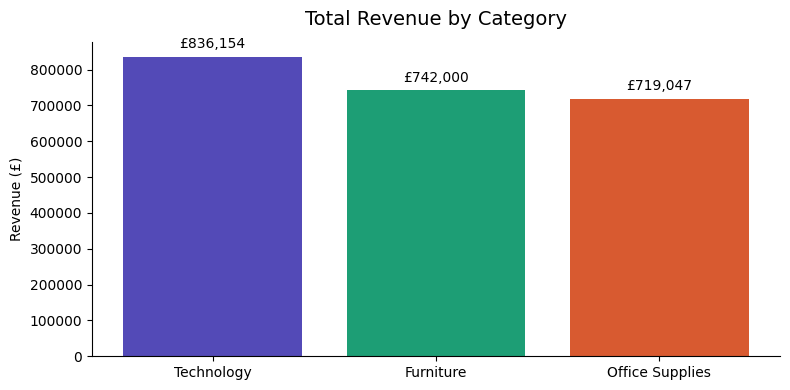

In [16]:
cat_df = pd.read_sql(q1, conn)

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(cat_df['Category'], cat_df['total_revenue'],
              color=['#534AB7','#1D9E75','#D85A30'])
ax.set_title('Total Revenue by Category', fontsize=14, pad=12)
ax.set_ylabel('Revenue (£)')
ax.bar_label(bars, fmt='£{:,.0f}', padding=4, fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("01_revenue_by_category.png", dpi=150)
plt.show()

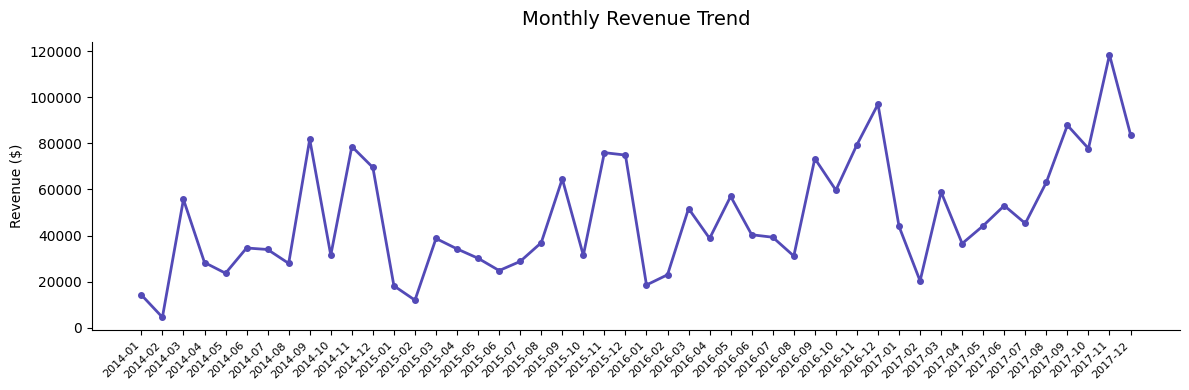

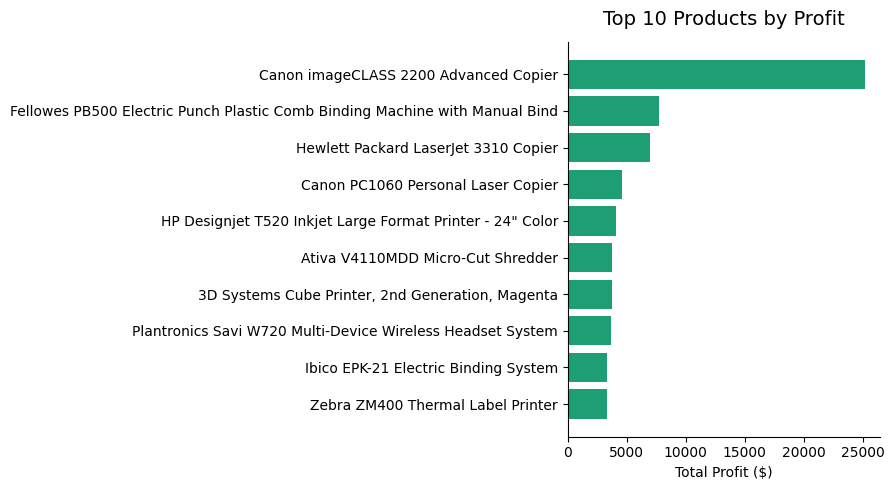

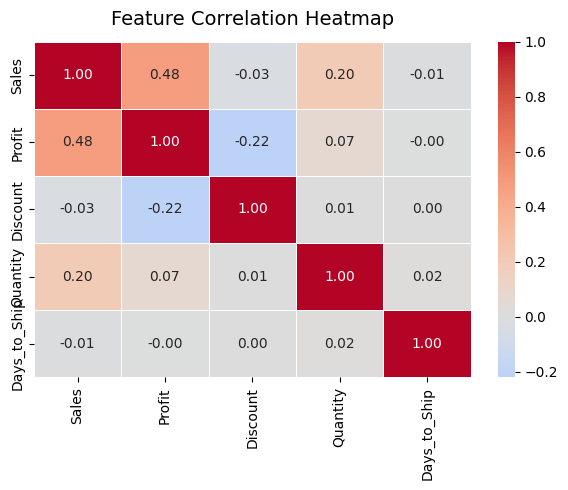

In [20]:
# Chart 2: Monthly revenue line chart
monthly = pd.read_sql(q2, conn)
monthly['period'] = monthly['Order_Year'].astype(str)+'-'+monthly['Order_Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(monthly['period'], monthly['monthly_revenue'],
        color='#534AB7', linewidth=2, marker='o', markersize=4)
ax.set_title('Monthly Revenue Trend', fontsize=14, pad=12)
ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("02_monthly_trend.png", dpi=150)
plt.show()

# Chart 3: Top 10 products horizontal bar
top10 = pd.read_sql(q3, conn)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(top10['Product_Name'], top10['total_profit'], color='#1D9E75')
ax.set_title('Top 10 Products by Profit', fontsize=14, pad=12)
ax.set_xlabel('Total Profit ($)')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("03_top_products.png", dpi=150)
plt.show()

# Chart 4: Profit correlation heatmap
fig, ax = plt.subplots(figsize=(6,5))
corr = df[['Sales','Profit','Discount','Quantity','Days_to_Ship']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("04_correlation_heatmap.png", dpi=150)
plt.show()
